# 2. XGBoost - Gradient Boosting Otimizado

## Descrição
XGBoost (Extreme Gradient Boosting) é um algoritmo de gradient boosting altamente otimizado que constrói sequencialmente árvores para corrigir erros dos modelos anteriores. Foi o melhor modelo no trabalho original (F1=0,7304) e serve como benchmark a ser superado.

## Características
- Gradient boosting sequencial
- Altamente otimizado para performance
- Suporta paralelização
- Fornece importância de características
- Benchmark do trabalho original

## Referências
- Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785-794).

## 1. Importações e Configurações

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
from pathlib import Path

# Paths agnósticos
def get_project_root():
    path = Path.cwd()
    for _ in range(6):
        if (path / 'dados' / 'data_treino.csv').exists() or (path / 'data_treino.csv').exists(): return path
        if (path / 'dados' / 'processados').is_dir(): return path
        path = path.parent
    return Path.cwd()
PROJECT_ROOT = get_project_root()
DIR_DADOS_PROCESSADOS = PROJECT_ROOT / 'dados' / 'processados'
DIR_MODELOS = PROJECT_ROOT / 'modelos'
DIR_GRAFICOS = PROJECT_ROOT / 'graficos'

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, auc
)
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

os.makedirs(DIR_GRAFICOS, exist_ok=True)
os.makedirs(DIR_MODELOS, exist_ok=True)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [10]:
with open(DIR_DADOS_PROCESSADOS / 'datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

X_train = datasets['baseline']['X_train']
X_val = datasets['baseline']['X_val']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_val = datasets['baseline']['y_val']
y_test = datasets['baseline']['y_test']

print(f"Dataset carregado: {datasets['baseline']['descricao']}")
print(f"Dimensões: X_train={X_train.shape}, X_test={X_test.shape}")

Dataset carregado: Mediana + StandardScaler + SelectKBest
Dimensões: X_train=(1730, 50), X_test=(372, 50)


## 3. Otimização de Hiperparâmetros

In [11]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

xgb_base = xgb.XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb_base,
    param_dist,
    n_iter=50,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Iniciando Random Search para XGBoost...")
random_search.fit(X_train, y_train)

print(f"\nMelhores hiperparâmetros:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-score (CV): {random_search.best_score_:.4f}")

Iniciando Random Search para XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores hiperparâmetros:
  subsample: 0.6
  reg_lambda: 1
  reg_alpha: 0.1
  n_estimators: 100
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.01
  gamma: 0
  colsample_bytree: 1.0

Melhor F1-score (CV): 0.7083


## 4. Treinamento e Avaliação

In [12]:
xgb_model = random_search.best_estimator_

# Predições
y_test_pred = xgb_model.predict(X_test)
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Métricas
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
test_pr_auc = auc(recall_vals, precision_vals)

print("="*70)
print("MÉTRICAS - XGBoost")
print("="*70)
print(f"Acurácia: {test_accuracy:.4f}")
print(f"Precisão: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")
print("="*70)

MÉTRICAS - XGBoost
Acurácia: 0.6102
Precisão: 0.6064
Recall: 0.8341
F1-Score: 0.7023
ROC-AUC: 0.6574
PR-AUC: 0.6921


## 5. Visualizações

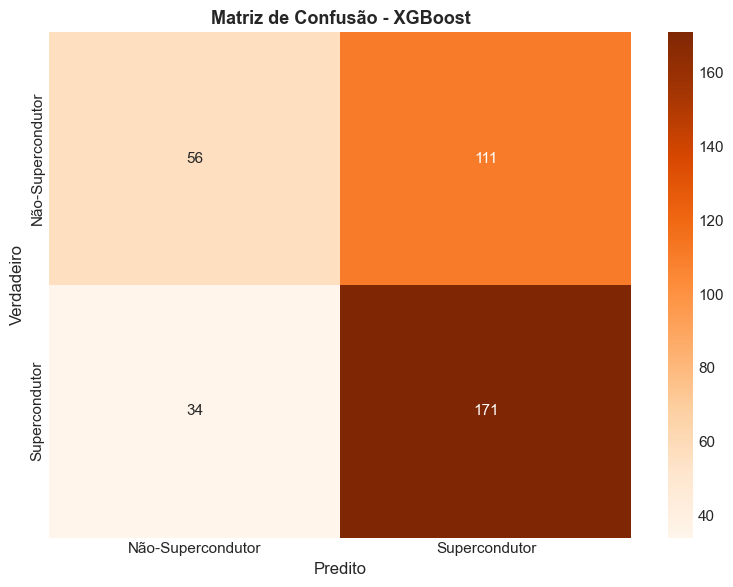

In [13]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=True, ax=ax,
            xticklabels=['Não-Supercondutor', 'Supercondutor'],
            yticklabels=['Não-Supercondutor', 'Supercondutor'])
ax.set_ylabel('Verdadeiro', fontsize=12)
ax.set_xlabel('Predito', fontsize=12)
ax.set_title('Matriz de Confusão - XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '02_xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

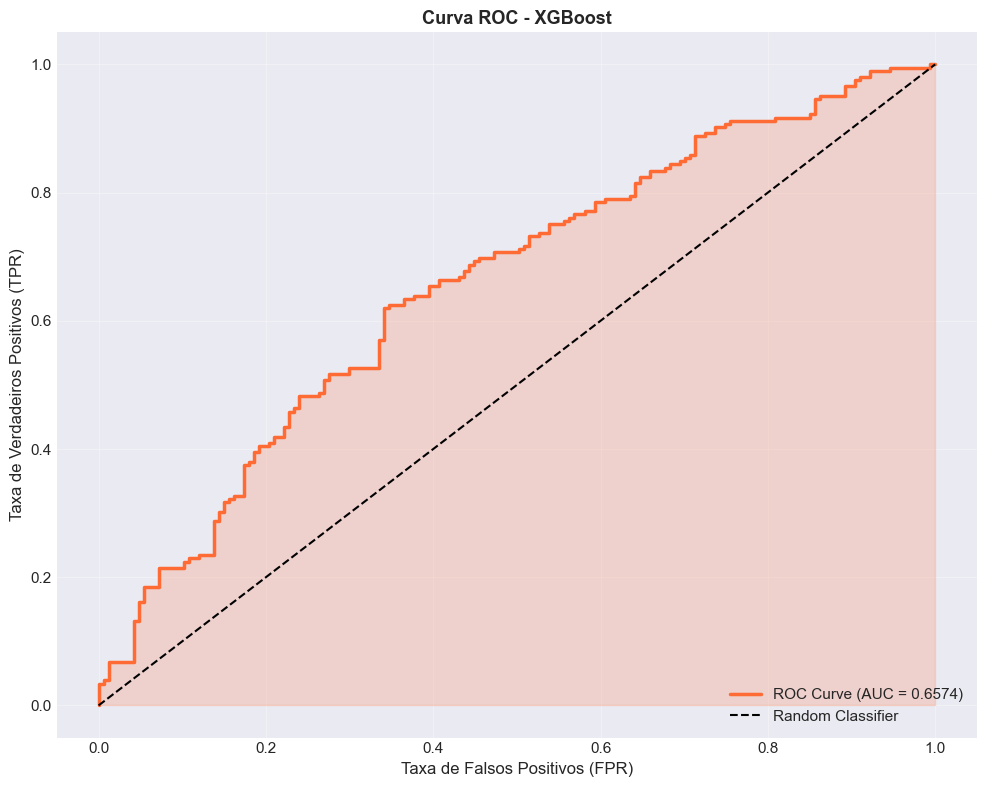

In [14]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_roc_auc:.4f})', linewidth=2.5, color='#FF6B35')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='#FF6B35')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC - XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '02_xgb_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

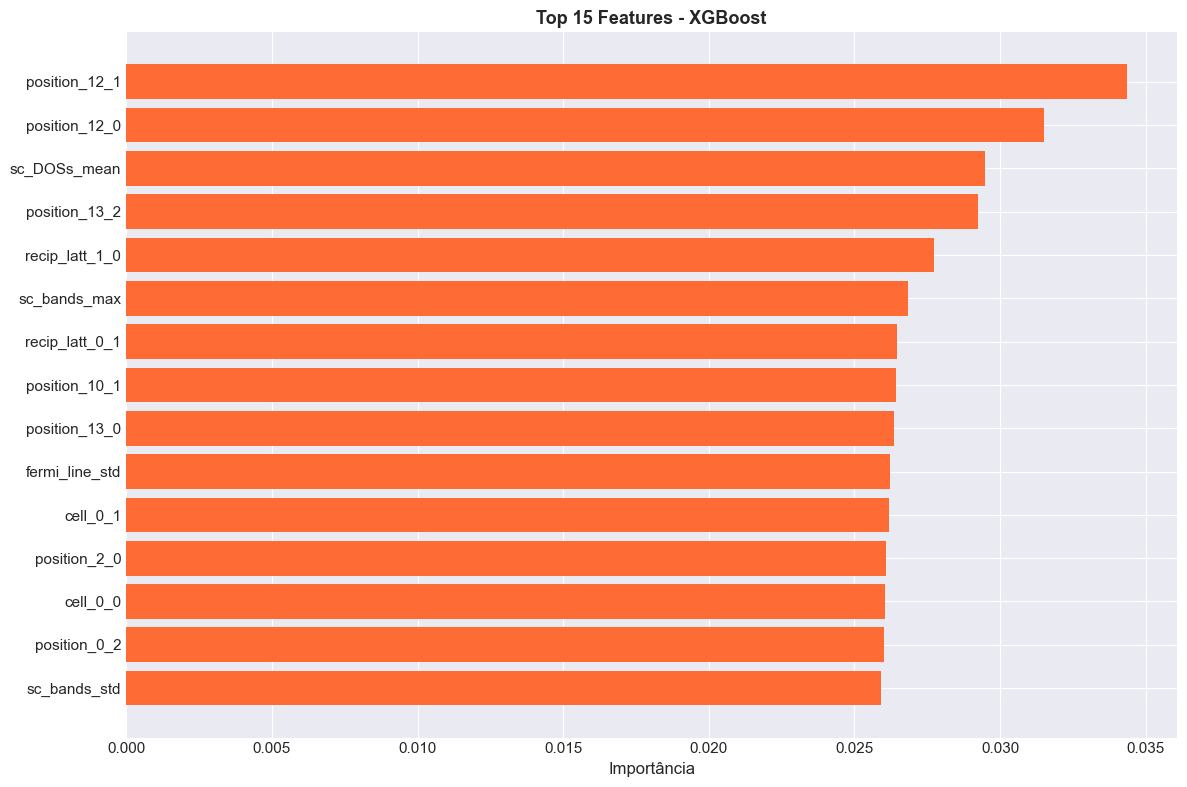

In [15]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values, color='#FF6B35')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importância', fontsize=12)
ax.set_title('Top 15 Features - XGBoost', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '02_xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Salvamento

In [16]:
joblib.dump(xgb_model, DIR_MODELOS / 'xgboost_model.pkl')

results = {
    'model_name': 'XGBoost',
    'best_params': random_search.best_params_,
    'metrics': {
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc
    },
    'feature_importance': feature_importance,
    'predictions': {
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba
    }
}

with open(DIR_MODELOS / 'xgboost_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Modelo XGBoost salvo com sucesso!")

Modelo XGBoost salvo com sucesso!
